# Este archivo se usa para estudiar el funcionamiento de la ecuación de Tait usando exactamente los parámetros del código de Andrés.

1. Traemos la configuración incial de Torricelli para realizar la estabilización.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

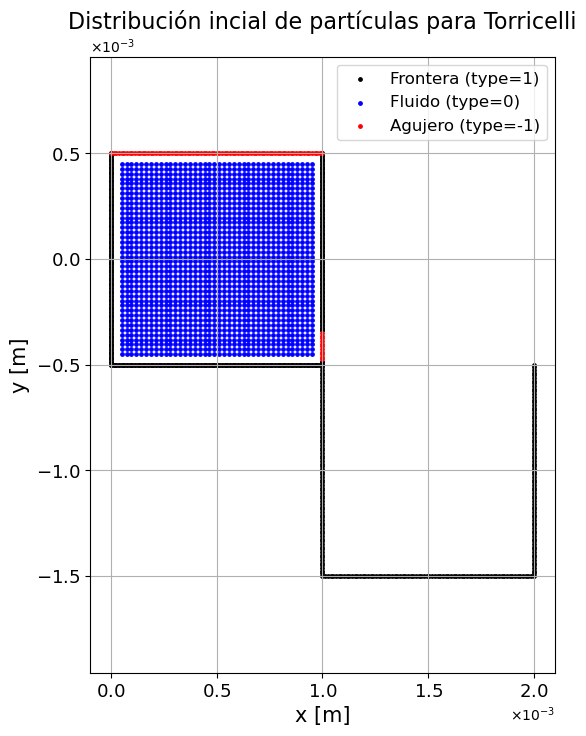

In [3]:
from Config.utils.plot_ics import plot_ics

PATH_OUTPUT_INIT_COND = f"{PROJECT_ROOT}/Output/init_cond"
INIT_COND_TORR_1E_3 = f"{PATH_OUTPUT_INIT_COND}/Torricelli/torricelli1e-3_geometry.txt"

plot_ics(INIT_COND_TORR_1E_3, title="Distribución incial de partículas para Torricelli")

2. Hacemos las cuentas haciendo uso de los parámetros encontrado de forma empírica:

$$ B = 1,\ c = 0.01\ m/s\ y\ dt = 5\times 10^{-5}\ s $$

In [4]:
from Config.utils.create_simJSON import create_simulation_config

create_simulation_config(
        experiment_name="Estab_Torricelli_40x401e-3_Emp",
        input_file=INIT_COND_TORR_1E_3,
        base_json="AndresSimParams.json",
        B=0.5,
        c=0.001,
        dt=5e-5,
        g=-9.8,
        steps=4000,
        project_dir=f"{PROJECT_ROOT}/Output/Torricelli",
        neighbor_method="quadtree",
        project_root=PROJECT_ROOT
    )

✅ params.json generado: Estab_Torricelli_40x401e-3_Emp/params.json


PosixPath('/media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-3_Emp/params.json')

In [5]:
from Config.utils.run_sim import run_single_simulation

run_single_simulation(
    experiment_dir=PROJECT_ROOT / "Output" / "Torricelli" / "Estab_Torricelli_40x401e-3_Emp",
    sim_executable=PROJECT_ROOT / "sim0pBoundLJ_qt-3",
    timeout_seconds=10000
)


🚀 Ejecutando simulación: Estab_Torricelli_40x401e-3_Emp

[INFO] Leyendo parámetros desde: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-3_Emp/params.json
[INFO] Configurada EoS Monaghan con parámetros:
       B=0.5, c=0.001, rho0=1000, gamma=7
Dentro de función de lectura de partículas
Separación dx/dy de frontera: 0, 0
Separación dx/dy de fluido: 0, 0
Primera partícula de frontera:
  ID: 0 pos: (0, 0.0005)
  tipo: Frontera
 h: 2.75e-05
Última partícula de fluido:
  ID: 2388 pos: (0.00095, 0.00045)
  tipo: Fluido
 h: 2.75e-05
Se leyeron 2389 partículas desde el archivo /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/init_cond/Torricelli/torricelli1e-3_geometry.txt

[particleSummary] Número total de partículas: 2389
Fluido: 1600, Ancho: 0.0009, Altura: 0.0009
Frontera: 789, Ancho: 0.002, Altura: 0.002
[INFO] Ejecutando test del kernel...
Prueba del kernel completada.
Resultados guardados

KeyboardInterrupt: 

In [6]:
from Config.utils.create_gnuplot import generar_script_gnuplot

BASE_PLOT = f"{PROJECT_ROOT}/Output/Torricelli/Estab_Torricelli_40x401e-3_Emp"
BASE_FILE = f"{BASE_PLOT}/Output/state_0000.txt"

generar_script_gnuplot(BASE_FILE,
                       lim=1900,
                       retardo=0.5,
                       nombre_salida="plot_est_torricelli1e-3_40x40.gp",
                       ruta_salida=BASE_PLOT
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Torricelli/Estab_Torricelli_40x401e-3_Emp/plot_est_torricelli1e-3_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–229 (230 partículas)
  Tipo -1: líneas 230–321 (92 partículas)
  Tipo 1: líneas 322–788 (467 partículas)
  Tipo 0: líneas 789–2388 (1600 partículas)


## Existe algún error que hace que la simulación con esos parámetros no sea tan estable como antes

Se trae desde FloodSPH la simulación en:

Output/Sim_Aparams_torricelli_1e-3

Que fue construida antes de usar las partículas tipo -1 para las fronteras por lo que hay que construir un nuevo archivo de gnuplot y con este detetectar hasta cuando ocurre la estabilización.

In [7]:
from Config.utils.create_gnuplot import generar_script_gnuplot

APAR_OUTPUT_PATH = f"{PROJECT_ROOT}/Output/Sim_Aparams_torricelli_1e-3"
APAR_FILE = f"{APAR_OUTPUT_PATH}/Output/state_0000.txt"

generar_script_gnuplot(APAR_FILE,
                       lim=10000,
                       retardo=1e-3,
                       nombre_salida="plot_est_torricelli1e-3_40x40.gp",
                       ruta_salida=APAR_OUTPUT_PATH
                       )

✅ Script Gnuplot generado correctamente: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Sim_Aparams_torricelli_1e-3/plot_est_torricelli1e-3_40x40.gp
📊 Rangos consecutivos detectados por tipo:
  Tipo 1: líneas 0–230 (231 partículas)
  Tipo -1: líneas 231–321 (91 partículas)
  Tipo 1: líneas 322–789 (468 partículas)
  Tipo 0: líneas 790–2389 (1600 partículas)


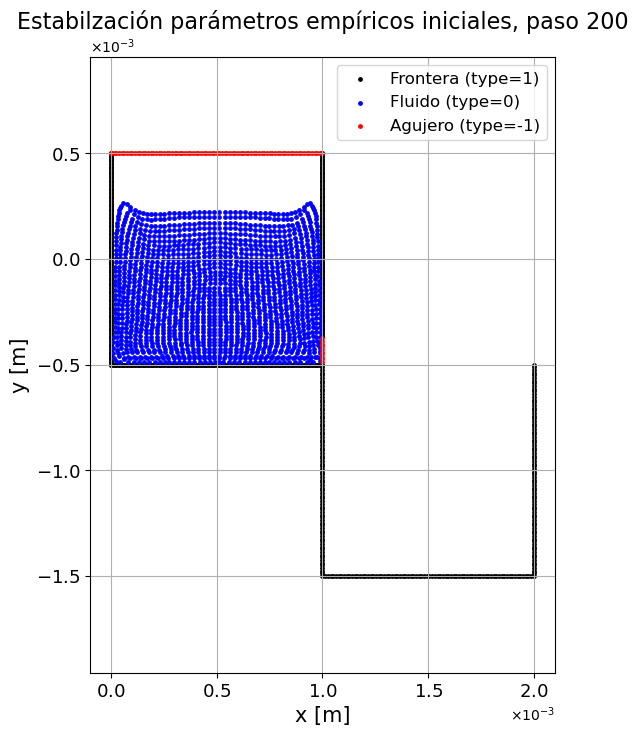

In [8]:
APAR_FILE_I_ESTAB = f"{APAR_OUTPUT_PATH}/Output/state_0200.txt"

plot_ics(APAR_FILE_I_ESTAB, title="Estabilzación parámetros empíricos iniciales, paso 200")

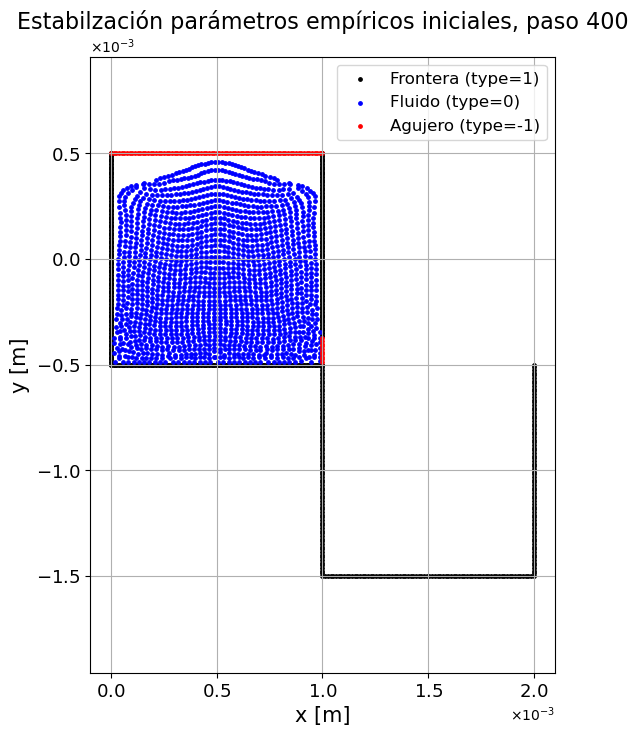

In [9]:
APAR_FILE_II_ESTAB = f"{APAR_OUTPUT_PATH}/Output/state_0400.txt"

plot_ics(APAR_FILE_II_ESTAB, title="Estabilzación parámetros empíricos iniciales, paso 400")

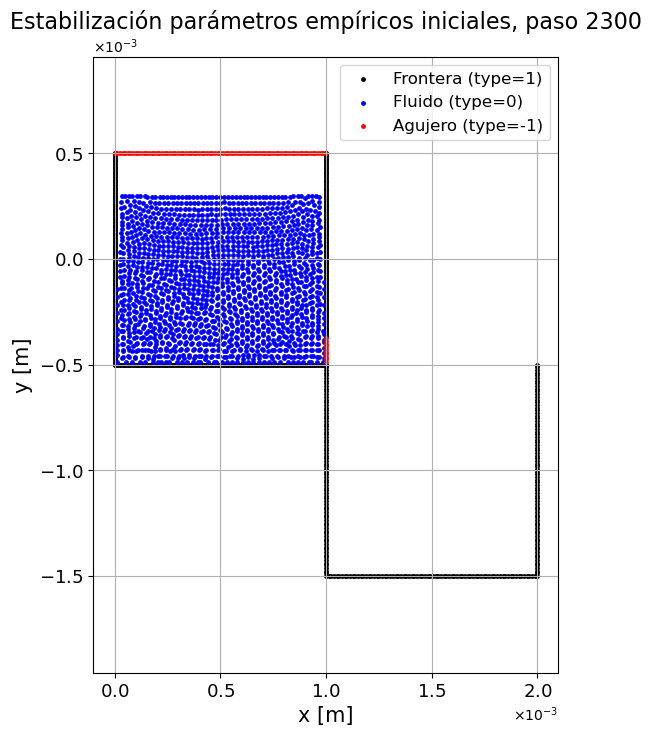

In [10]:
APAR_FILE_F_ESTAB = f"{APAR_OUTPUT_PATH}/Output/state_2300.txt"

plot_ics(APAR_FILE_F_ESTAB, title="Estabilización parámetros empíricos iniciales, paso 2300")

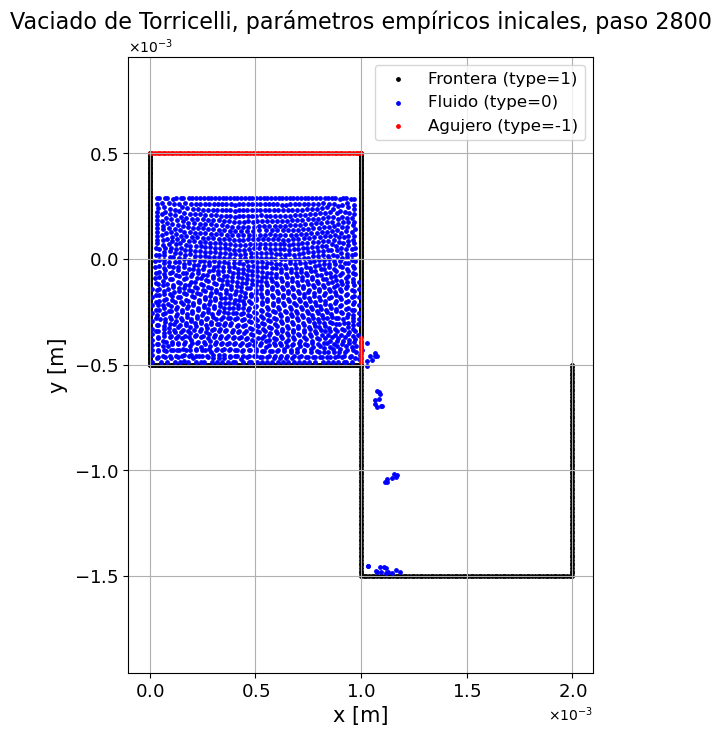

In [11]:
APAR_FILE_VAC = f"{APAR_OUTPUT_PATH}/Output/state_2800.txt"

plot_ics(APAR_FILE_VAC, title="Vaciado de Torricelli, parámetros empíricos inicales, paso 2800")

In [12]:
import pandas as pd

# Cargar archivo (usa el nombre correcto)
df = pd.read_csv(str(APAR_FILE_VAC), sep='\s+')

# Eliminar filas donde type == -1
df = df[df["type"] != -1]

In [13]:
if (df["type"] == -1).any():
    print("Aún quedan filas con type == -1")
else:
    print("Verificación OK: no queda ninguna fila con type == -1")

Verificación OK: no queda ninguna fila con type == -1


In [14]:
# ---- Ruta donde guardar ----
nombre_archivo = "Open_torricelli_Andres_40x40_1e-3.txt"

OPEN_VAC = Path(APAR_OUTPUT_PATH) / "Output" / nombre_archivo
# ---- Guardado con formateo EXACTO ----
with open(OPEN_VAC, "w") as f:
    
    # Escribir cabecera
    f.write("id posx posy velx vely accelx accely rho mass pressure h internalE type\n")
    
    # Escribir cada fila con formateo específico
    for _, row in df.iterrows():
        f.write(
            f"{int(row['id'])} "
            f"{row['posx']:.10f} "
            f"{row['posy']:.10f} "
            f"{row['velx']:.10f} "
            f"{row['vely']:.10f} "
            f"{row['accelx']:.10f} "
            f"{row['accely']:.10f} "
            f"{row['rho']:.10f} "
            f"{row['mass']:.10f} "
            f"{row['pressure']:.10f} "
            f"{row['h']:.10f} "
            f"{row['internalE']:.10f} "
            f"{int(row['type'])}\n"
        )

print("Archivo guardado en:", OPEN_VAC)

Archivo guardado en: /media/hvarkaed/a2e590e8-6eb4-4da7-a766-06b1247531ca/NeighboorsFloodSPH/Output/Sim_Aparams_torricelli_1e-3/Output/Open_torricelli_Andres_40x40_1e-3.txt


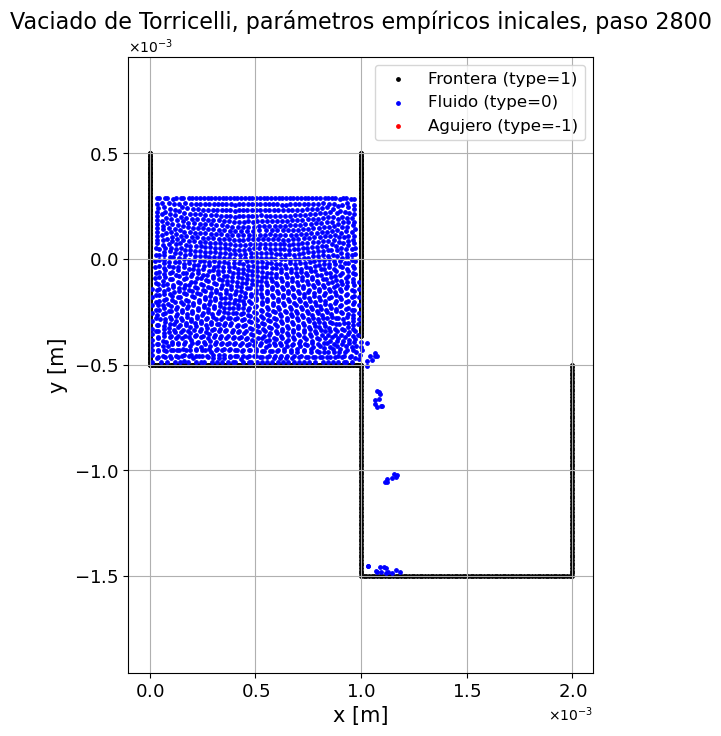

In [15]:
plot_ics(OPEN_VAC, title="Vaciado de Torricelli, parámetros empíricos inicales, paso 2800")